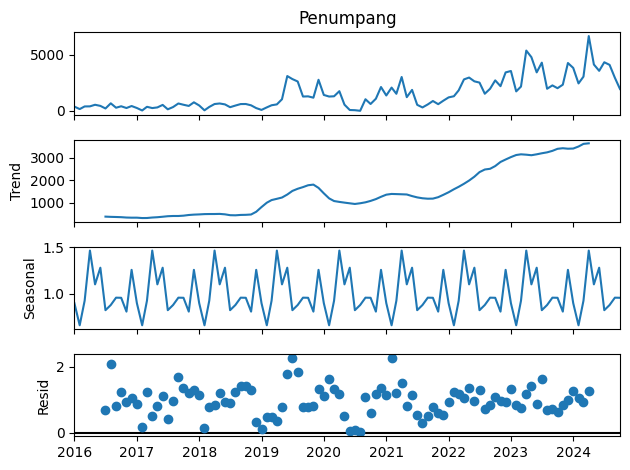

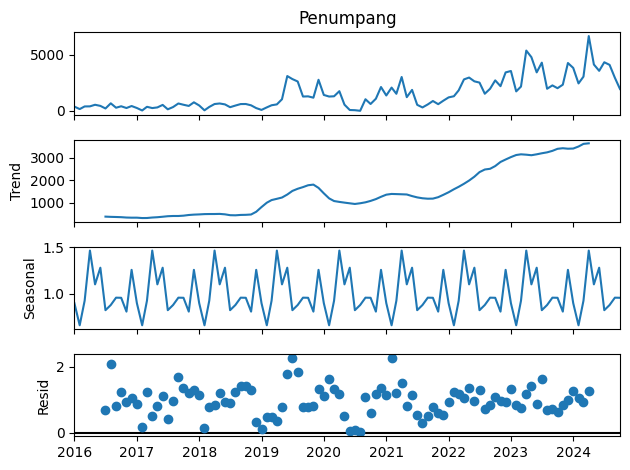

In [1]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from statsmodels.tsa.seasonal import seasonal_decompose 
  
# Read the AirPassengers dataset 
sea_passanger = pd.read_csv('Penumpang_Gorontalo.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  
# Print the first five rows of the dataset 
sea_passanger.head(5) 
  
# ETS Decomposition 
result = seasonal_decompose(sea_passanger['Penumpang'],  
                            model ='multiplicative') 
  
# ETS plot  
result.plot() 


In [2]:
# Import the library 
from pmdarima import auto_arima 

# Ignore harmless warnings 
import warnings 
warnings.filterwarnings("ignore") 

# Fit auto_arima function to AirPassengers dataset 
stepwise_fit = auto_arima(sea_passanger['Penumpang'], start_p = 1, start_q = 1, 
						max_p = 3, max_q = 3, m = 12, 
						start_P = 0, seasonal = True, 
						d = None, D = 1, trace = True, 
						error_action ='ignore', # we don't want to know if an order does not work 
						suppress_warnings = True, # we don't want convergence warnings 
						stepwise = True)		 # set to stepwise 

# To print the summary 
stepwise_fit.summary() 


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=1521.211, Time=0.72 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1577.127, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1525.396, Time=0.50 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1533.342, Time=0.56 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1589.021, Time=0.04 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=1534.587, Time=0.21 sec
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=1522.977, Time=0.90 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=1522.625, Time=1.90 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=1526.954, Time=0.68 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=1523.147, Time=3.39 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=1519.475, Time=0.44 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1533.044, Time=0.08 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1521.214, Time=0.71 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AIC=1520.902, Time=1.53 sec
 ARIMA(1,0,0)(1,1,2

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  106
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -755.737
Date:                              Wed, 04 Jun 2025   AIC                           1519.475
Time:                                      09:24:49   BIC                           1529.648
Sample:                                  01-01-2016   HQIC                          1523.584
                                       - 10-01-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    149.2130     61.008      2.446      0.014      29.639     268.787
ar.L1          0.6168      0.082      7.567      0.000       0.457       0.777
ma.S.L12      -0.4937      0.078     -6.312      0.000      -0.647      -0.340
sigma2      5.513e+05   7.44e+04      7.410      0.000    4.05e+05    6.97e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 7.76
Prob(Q):                              0.77   Prob(JB):                         0.02
Heteroskedasticity (H):               3.94   Skew:                             0.59
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [3]:
# Split data into train / test sets 
train = sea_passanger.iloc[:len(sea_passanger)-12] 
test = sea_passanger.iloc[len(sea_passanger)-12:] # set one year(12 months) for testing 

# Fit a SARIMAX(0, 1, 1)x(2, 1, 1, 12) on the training set 
from statsmodels.tsa.statespace.sarimax import SARIMAX 

model = SARIMAX(train['Penumpang'], 
				order = (1, 0, 0), 
				seasonal_order =(0, 1, 1, 12)) 

result = model.fit() 
result.summary() 


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                            Penumpang   No. Observations:                   94
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -658.683
Date:                              Wed, 04 Jun 2025   AIC                           1323.365
Time:                                      09:26:24   BIC                           1330.586
Sample:                                  01-01-2016   HQIC                          1326.264
                                       - 10-01-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7595      0.066     11.576      0.000       0.631       0.888
ma.S.L12      -0.4971      0.100     -4.994      0.000      -0.692      -0.302
sigma2      5.406e+05   6.47e+04      8.354      0.000    4.14e+05    6.67e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.90   Jarque-Bera (JB):                 9.94
Prob(Q):                              0.17   Prob(JB):                         0.01
Heteroskedasticity (H):              17.49   Skew:                             0.57
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Tahun'>

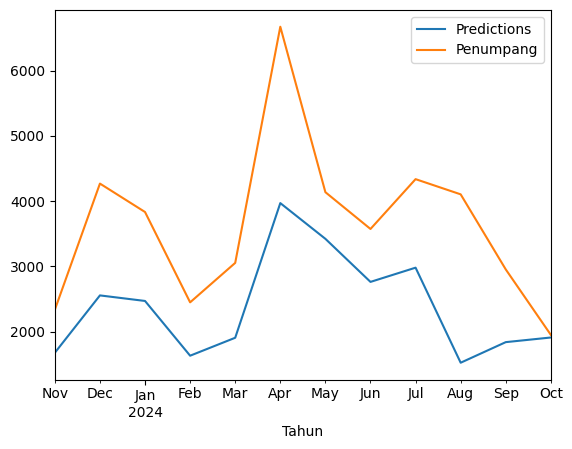

In [4]:
start = len(train) 
end = len(train) + len(test) - 1

# Predictions for one-year against the test set 
predictions = result.predict(start, end, 
							typ = 'levels').rename("Predictions") 

# plot predictions and actual values 
predictions.plot(legend = True) 
test['Penumpang'].plot(legend = True) 


In [5]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse 

# Calculate root mean squared error 
rmse(test["Penumpang"], predictions) 



1456.5187033836037

In [6]:
# Calculate mean squared error 
mean_squared_error(test["Penumpang"], predictions) 


2121446.7333062543

In [7]:
# Calculate mean absolute error 
mean_absolute_error(test["Penumpang"], predictions) 


1252.4146389200312

In [8]:
# R squared
r2_score(test["Penumpang"], predictions) 


-0.4638627300494884

In [9]:
# MAPE
mean_absolute_percentage_error(test['Penumpang'], predictions)

0.32471236946231957

<Axes: xlabel='Tahun'>

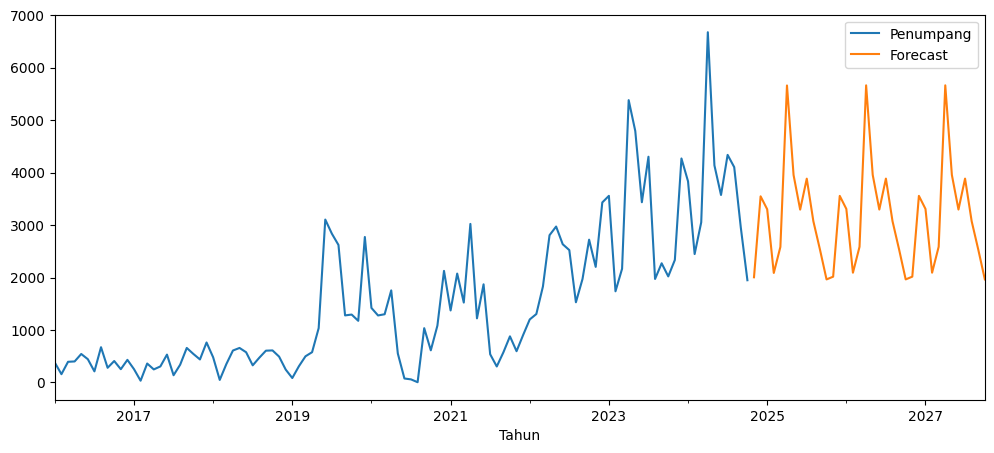

In [24]:
# Train the model on the full dataset 
model = model = SARIMAX(sea_passanger['Penumpang'], 
						order = (1, 0, 0), 
						seasonal_order =(0, 1, 1, 12)) 
result = model.fit() 

# Forecast for the next 3 years 
forecast = result.predict(start = len(sea_passanger), 
						end = (len(sea_passanger)-1) + 3 * 12, 
						typ = 'levels').rename('Forecast') 

# Plot the forecast values 
sea_passanger['Penumpang'].plot(figsize = (12, 5), legend = True) 
forecast.plot(legend = True) 


<Axes: xlabel='Tahun'>

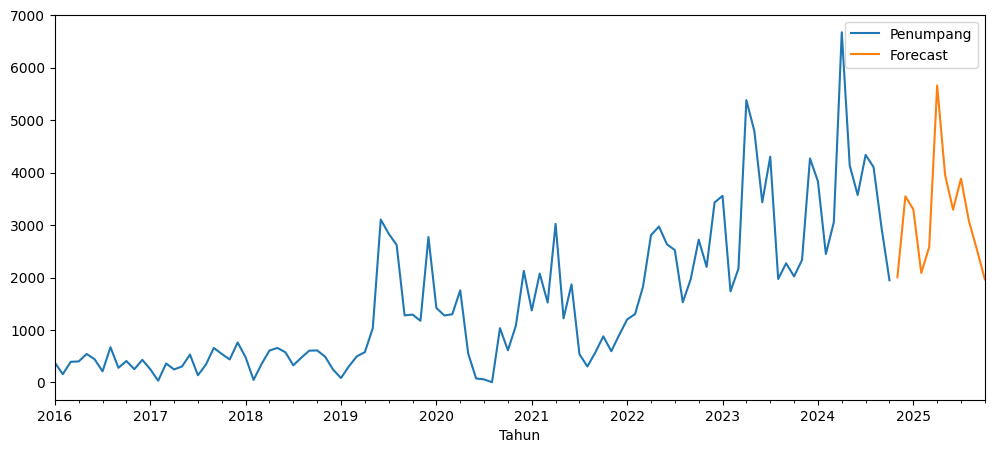

In [10]:
# Train the model on the full dataset 
model = model = SARIMAX(sea_passanger['Penumpang'], 
						order = (1, 0, 0), 
						seasonal_order =(0, 1, 1, 12)) 
result = model.fit() 

# Forecast for the next 3 years 
forecast = result.predict(start = len(sea_passanger), 
						end = (len(sea_passanger)-1) + 1 * 12, 
						typ = 'levels').rename('Forecast') 

# Plot the forecast values 
sea_passanger['Penumpang'].plot(figsize = (12, 5), legend = True) 
forecast.plot(legend = True) 


In [11]:
# Train the model on the full dataset 
model = model = SARIMAX(sea_passanger['Penumpang'], 
						order = (1, 0, 0), 
						seasonal_order =(0, 1, 1, 12)) 
result = model.fit() 

# Forecast for the next 3 years 
forecast = result.predict(start = len(sea_passanger), 
						end = (len(sea_passanger)-1) + 1 * 12, 
						typ = 'levels').rename('Forecast') 

print(forecast)


2024-11-01    2004.307712
2024-12-01    3546.597196
2025-01-01    3300.055936
2025-02-01    2086.560855
2025-03-01    2582.219922
2025-04-01    5658.566400
2025-05-01    3952.701652
2025-06-01    3293.222544
2025-07-01    3883.409047
2025-08-01    3072.355388
2025-09-01    2533.116329
2025-10-01    1963.577386
Freq: MS, Name: Forecast, dtype: float64
